In [2]:
import pandas as pd

df = pd.read_csv("../data/BankChurners.csv")
df = df.drop(columns=["CLIENTNUM"] + [c for c in df.columns if c.startswith("Naive_Bayes")])
df["churn"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

print(df.shape)
print(df["churn"].mean())
df.head()


(10127, 21)
0.1606596227905599


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  str    
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Open_To_Buy  

In [4]:
for col in ["Education_Level", "Marital_Status", "Income_Category"]:
    print(df[col].value_counts(), "\n")

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64 

Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64 

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64 



In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


In [6]:
print("Duplicates:", df.duplicated().sum())
print(df["Attrition_Flag"].value_counts())
print(df["Attrition_Flag"].value_counts(normalize=True))

Duplicates: 0
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


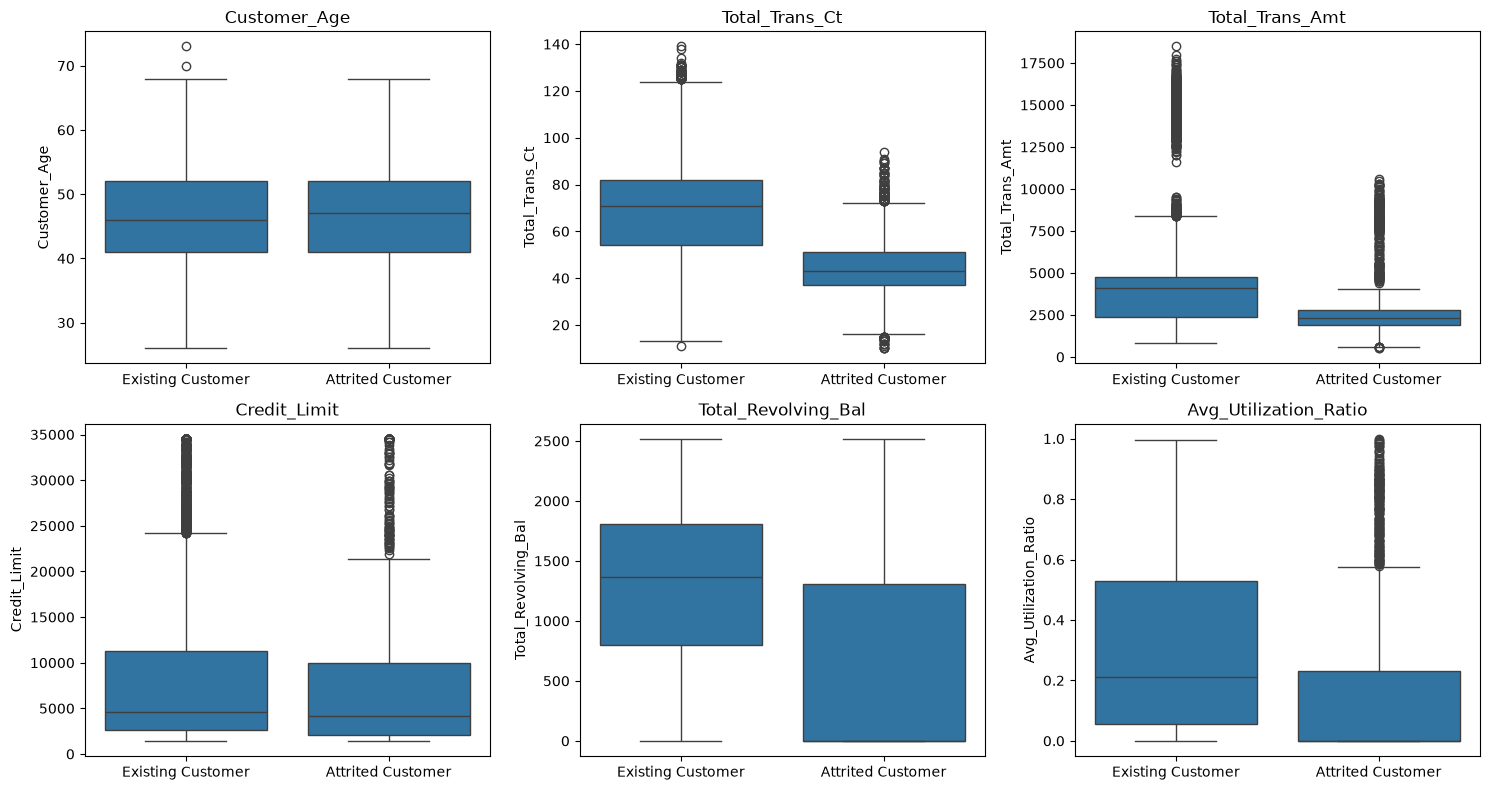

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["Customer_Age", "Total_Trans_Ct", "Total_Trans_Amt", "Credit_Limit",
            "Total_Revolving_Bal", "Avg_Utilization_Ratio"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x="Attrition_Flag", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

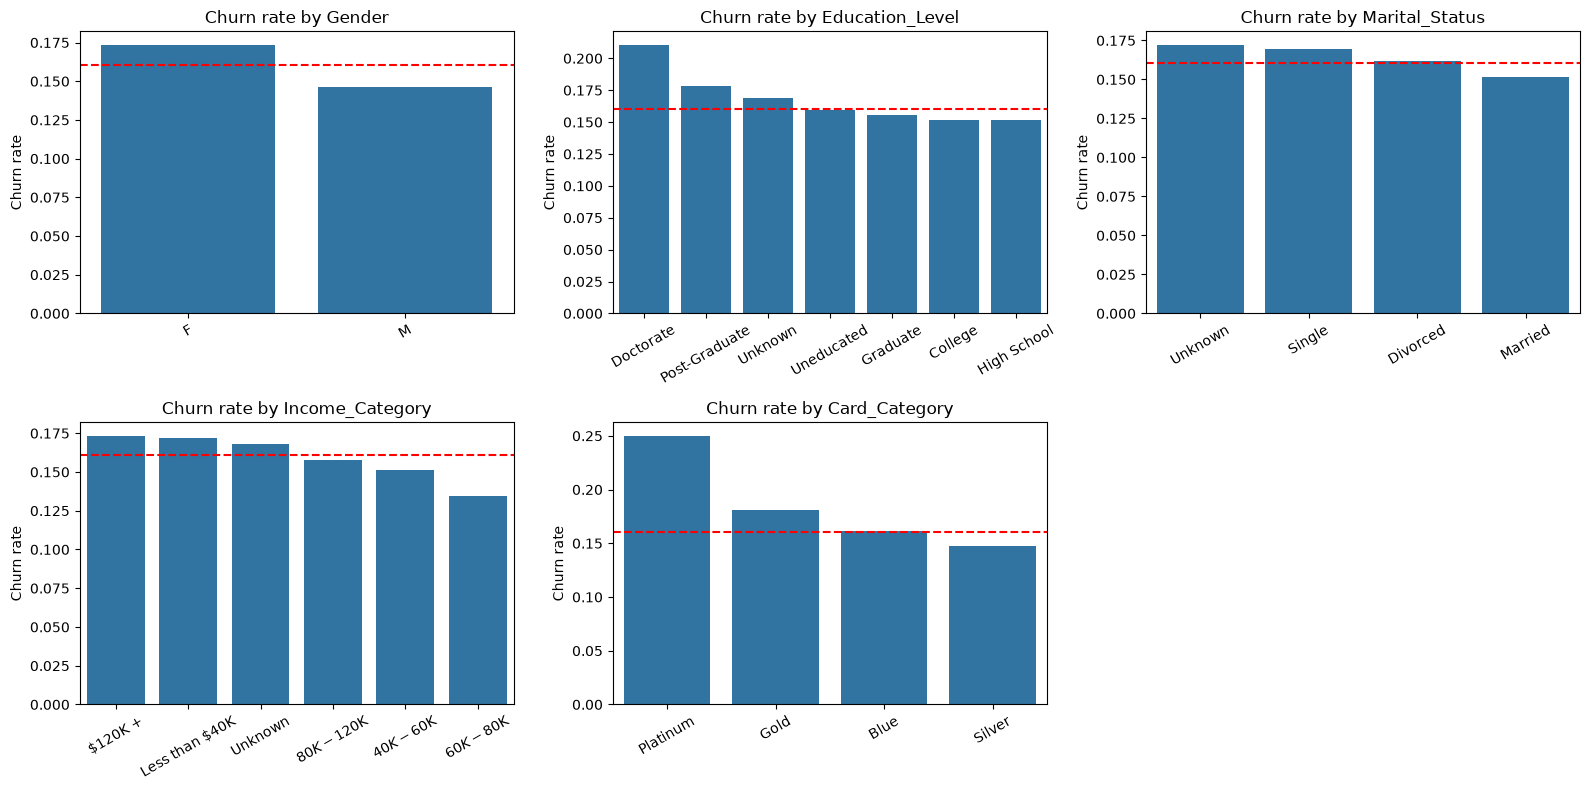

In [8]:
cat_cols = ["Gender", "Education_Level", "Marital_Status",
            "Income_Category", "Card_Category"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(df["churn"].mean(), color="red", linestyle="--")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

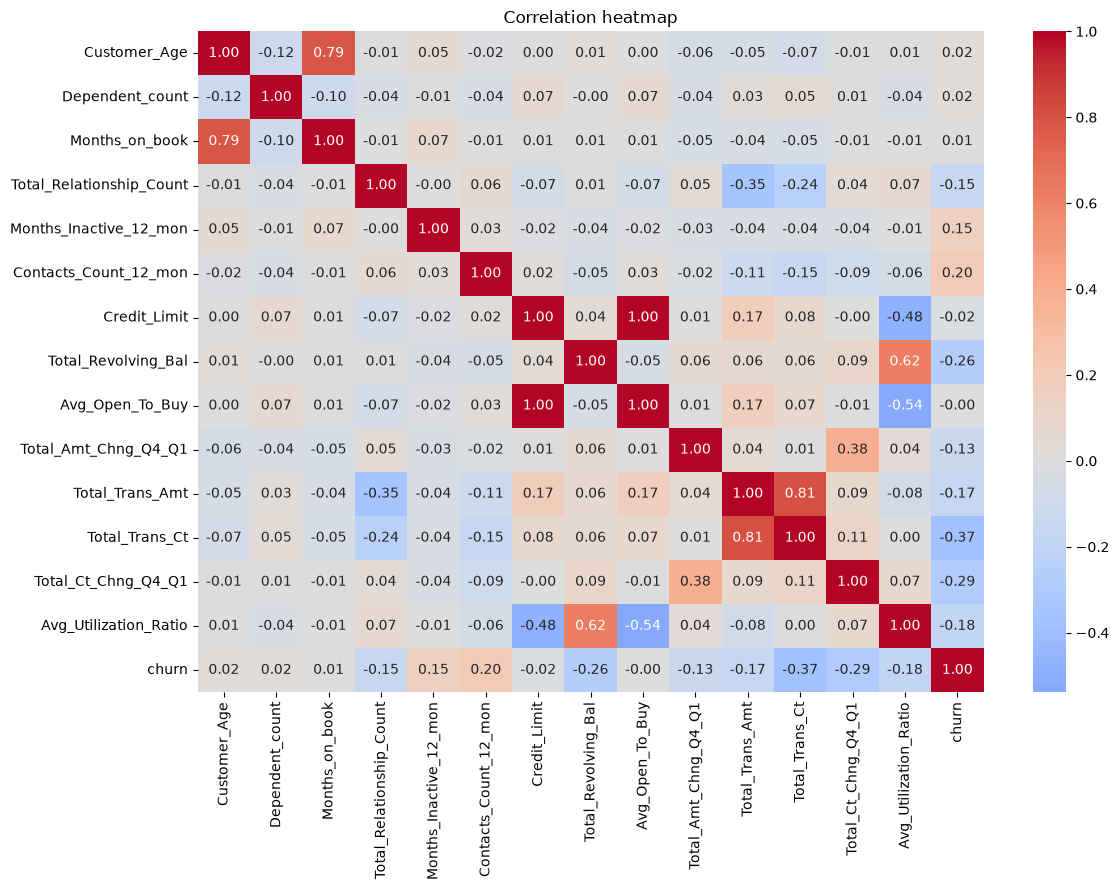

In [9]:
num_df = df.select_dtypes(include="number")
plt.figure(figsize=(12, 9))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [10]:
df_model = df.drop(columns=["Avg_Open_To_Buy", "Attrition_Flag"])
X = df_model.drop(columns=["churn"])
y = df_model["churn"]
print(X.shape, y.shape)

(10127, 18) (10127,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Churn rate train:", round(y_train.mean(), 4))
print("Churn rate test: ", round(y_test.mean(), 4))

Train: (8101, 18) Test: (2026, 18)
Churn rate train: 0.1607
Churn rate test:  0.1604


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Income has a natural order, so we encode it as ordered numbers
income_order = ["Unknown", "Less than $40K", "$40K - $60K",
                "$60K - $80K", "$80K - $120K", "$120K +"]

ordinal_cols = ["Income_Category"]
onehot_cols = ["Gender", "Education_Level", "Marital_Status", "Card_Category"]
numeric_cols = [c for c in X_train.columns if c not in ordinal_cols + onehot_cols]

print("Numeric:", numeric_cols)

Numeric: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [13]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("ord", OrdinalEncoder(categories=[income_order]), ordinal_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols),
])

# Learn from TRAIN only, then apply to both
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print("Before:", X_train.shape, "After:", X_train_p.shape)

Before: (8101, 18) After: (8101, 27)


In [14]:
print(X_train_p.shape, X_test_p.shape)

(8101, 27) (2026, 27)


In [15]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

lr = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

res = cross_validate(lr, X_train, y_train, cv=cv, scoring=scoring)
print({k: round(res[f"test_{k}"].mean(), 3) for k in scoring})

{'roc_auc': np.float64(0.926), 'pr_auc': np.float64(0.749), 'precision': np.float64(0.519), 'recall': np.float64(0.846), 'f1': np.float64(0.643)}


In [16]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# Ratio of non-churners to churners (about 5.2), used to handle imbalance in XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=pos_weight, eval_metric="logloss", random_state=42),
}

rows = {}
for name, model in models.items():
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", model)])
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows[name] = {k: round(r[f"test_{k}"].mean(), 3) for k in scoring}

results = pd.DataFrame(rows).T
results

,roc_auc,pr_auc,precision,recall,f1
Logistic Regression,0.926,0.749,0.519,0.846,0.643
Random Forest,0.989,0.945,0.876,0.888,0.882
XGBoost,0.992,0.966,0.857,0.939,0.896


In [17]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 8),
    }
    pipe = Pipeline([
        ("prep", clone(preprocessor)),
        ("model", XGBClassifier(**params, eval_metric="logloss",
                                random_state=42, n_jobs=-1)),
    ])
    return cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring="average_precision").mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

pri

NameError: name 'pri' is not defined

In [18]:
print("Best PR-AUC:", round(study.best_value, 4))
print(study.best_params)

Best PR-AUC: 0.9722
{'n_estimators': 325, 'max_depth': 4, 'learning_rate': 0.07081666627838669, 'subsample': 0.7772910739106629, 'colsample_bytree': 0.6584681769412739, 'scale_pos_weight': 2.838173680604188}


In [19]:
import numpy as np
from sklearn.model_selection import cross_val_predict

final_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", XGBClassifier(**study.best_params, eval_metric="logloss",
                            random_state=42, n_jobs=-1)),
])

# Each training row gets a probability from a model that never saw it
oof_proba = cross_val_predict(final_pipe, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]

Best threshold: 0.18
Net value at best threshold: ₹ 1576599


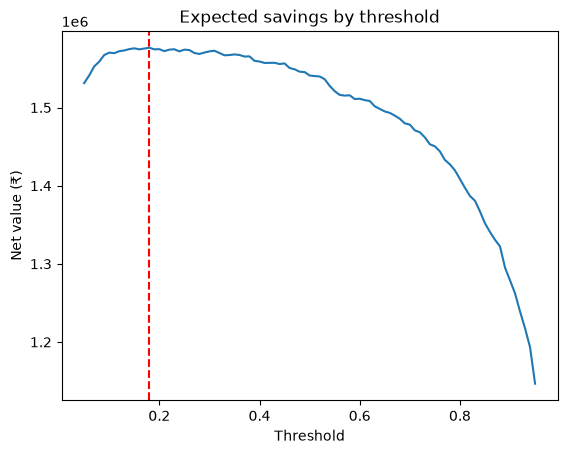

In [20]:
CALL_COST = 200     # ₹ per retention call
LOSS = 5000         # ₹ lost if a customer churns
SAVE_RATE = 0.3     # assumption: 30% of called churners are retained

y_arr = y_train.values
thresholds = np.arange(0.05, 0.96, 0.01)

def net_value(t):
    pred = oof_proba >= t
    tp = (pred & (y_arr == 1)).sum()
    fp = (pred & (y_arr == 0)).sum()
    return tp * SAVE_RATE * LOSS - (tp + fp) * CALL_COST

values = [net_value(t) for t in thresholds]
best_t = thresholds[int(np.argmax(values))]
print("Best threshold:", round(best_t, 2))
print("Net value at best threshold: ₹", int(max(values)))

plt.plot(thresholds, values)
plt.axvline(best_t, color="red", linestyle="--")
plt.xlabel("Threshold"); plt.ylabel("Net value (₹)")
plt.title("Expected savings by threshold")
plt.show()

In [21]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)

final_pipe.fit(X_train, y_train)
test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

print("ROC-AUC:  ", round(roc_auc_score(y_test, test_proba), 3))
print("PR-AUC:   ", round(average_precision_score(y_test, test_proba), 3))
print("Precision:", round(precision_score(y_test, test_pred), 3))
print("Recall:   ", round(recall_score(y_test, test_pred), 3))
print("F1:       ", round(f1_score(y_test, test_pred), 3))
print(confusion_matrix(y_test, test_pred))

ROC-AUC:   0.993
PR-AUC:    0.968
Precision: 0.787
Recall:    0.957
F1:        0.864
[[1617   84]
 [  14  311]]


In [22]:
import joblib
joblib.dump({"pipeline": final_pipe, "threshold": float(best_t)}, "models/churn_model.joblib")

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_model.joblib'

In [23]:
import joblib
joblib.dump({"pipeline": final_pipe, "threshold": float(best_t)}, "../models/churn_model.joblib")

['../models/churn_model.joblib']

In [24]:
import os
print(os.listdir("../models"))
print(round(os.path.getsize("../models/churn_model.joblib") / 1024), "KB")

['.gitkeep', 'churn_model.joblib']
502 KB
